# Preliminary supervised mapping of the 8 vegetation parent clusters

This notebook tests the direct supervised, RAP-like shortcut:

**IA45 annual harmonic features → vegetation parent label**

Only the eight broad vegetation parent clusters are modeled.

The experiment uses the existing point-level IA45 extraction for training and produces preliminary classified rasters only for:

- 2016
- 2018
- 2025

All raster prediction is constrained by:

`C:\NCA_DATA\templates\keepMask_wc_v200_2021_noCropBuiltWater_buf1.tif`

All tables, figures, and classified TIFFs are written to:

`C:\NCA_DATA\Analysis`

The subclusters are deliberately excluded from this preliminary model.


In [2]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)

# =============================================================================
# PATHS
# =============================================================================

TRAINING_CSV = Path(
    r"A:\NCA_DATA\Validation\Supervised_State_Classification"
    r"\FieldVeg_K2_IA45_Training.csv"
)

HARMONIC_ROOT = Path(
    r"A:\NCA_DATA\S2_Harmonics"
)

KEEP_MASK = Path(
    r"C:\NCA_DATA\templates\keepMask_wc_v200_2021_noCropBuiltWater_buf1.tif"
)

OUTPUT_DIR = Path(
    r"C:\NCA_DATA\Analysis\PrelimML_NoSpectralClustering"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Output directory:", OUTPUT_DIR)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

YEARS_TO_MAP = [
    2016,
    2018,
    2025,
]

EXPECTED_D = 45
CLASS_LABELS = np.arange(1, 9, dtype=int)

RANDOM_STATE = 42
N_SPLITS = 5

# Manual choice after inspecting validation.
MODEL_FOR_MAPPING = "random_forest"

# Keep raster volume restrained.
WRITE_UNCERTAINTY_RASTER = True
WRITE_CLASS_PROBABILITY_RASTER = True

COMPRESS = "DEFLATE"

print("Training data:", TRAINING_CSV)
print("Keep mask:", KEEP_MASK)
print("Output directory:", OUTPUT_DIR)
print("Years to map:", YEARS_TO_MAP)


Output directory: C:\NCA_DATA\Analysis\PrelimML_NoSpectralClustering
Training data: A:\NCA_DATA\Validation\Supervised_State_Classification\FieldVeg_K2_IA45_Training.csv
Keep mask: C:\NCA_DATA\templates\keepMask_wc_v200_2021_noCropBuiltWater_buf1.tif
Output directory: C:\NCA_DATA\Analysis\PrelimML_NoSpectralClustering
Years to map: [2016, 2018, 2025]


## 1. Load 2016, 2018, and 2025 field observations


In [3]:
# =============================================================================
# LOAD TRAINING DATA
# =============================================================================

if not TRAINING_CSV.exists():
    raise FileNotFoundError(
        f"Training CSV not found:\n{TRAINING_CSV}"
    )

df = pd.read_csv(
    TRAINING_CSV,
    low_memory=False,
).drop(
    columns=["Unnamed: 0"],
    errors="ignore",
)

required = {
    "PlotID",
    "Year",
    "parent_cluster",
}

missing = required - set(df.columns)

if missing:
    raise KeyError(
        f"Training data missing columns: {sorted(missing)}"
    )

df["Year"] = pd.to_numeric(
    df["Year"],
    errors="coerce",
)

df["parent_cluster"] = pd.to_numeric(
    df["parent_cluster"],
    errors="coerce",
)

df = (
    df.loc[
        df["Year"].isin(YEARS_TO_MAP)
        & df["parent_cluster"].notna()
    ]
    .copy()
    .reset_index(drop=True)
)

df["Year"] = df["Year"].astype(int)
df["parent_cluster"] = df["parent_cluster"].astype(int)
df["PlotID"] = df["PlotID"].astype(str).str.strip()

print("Training rows:", f"{len(df):,}")

display(
    df.groupby(
        ["Year", "parent_cluster"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "n"})
)

observed_classes = sorted(
    df["parent_cluster"].unique().tolist()
)

print("Observed parent classes:", observed_classes)

if observed_classes != CLASS_LABELS.tolist():
    warnings.warn(
        f"Expected classes {CLASS_LABELS.tolist()}, "
        f"observed {observed_classes}."
    )


Training rows: 479


,Year,parent_cluster,n
0,2016,1,42
1,2016,2,28
2,2016,3,42
3,2016,4,43
4,2016,5,46
5,2016,6,24
6,2016,7,19
7,2016,8,11
8,2018,1,11
9,2018,2,17


Observed parent classes: [1, 2, 3, 4, 5, 6, 7, 8]


## 2. Identify the same 45 intercept/amplitude predictors used in the point extraction


In [4]:
# =============================================================================
# IA45
# =============================================================================

intercept_cols = [
    c for c in df.columns
    if re.search(
        r"^(constant_|intercept_)",
        str(c),
        flags=re.IGNORECASE,
    )
]

amplitude_cols = [
    c for c in df.columns
    if re.search(
        r"^(amp|amplitude)",
        str(c),
        flags=re.IGNORECASE,
    )
]

IA_COLS = intercept_cols + amplitude_cols

print("Intercept:", len(intercept_cols))
print("Amplitude:", len(amplitude_cols))
print("Total IA:", len(IA_COLS))

if len(IA_COLS) != EXPECTED_D:
    raise ValueError(
        f"Expected {EXPECTED_D} IA predictors; found {len(IA_COLS)}."
    )

X_df = (
    df[IA_COLS]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
)

bad = X_df.isna().any(axis=1)

if bad.any():
    display(
        df.loc[
            bad,
            ["PlotID", "Year", "parent_cluster"],
        ].head(50)
    )
    raise ValueError(
        f"{int(bad.sum()):,} rows contain incomplete IA45 predictors."
    )

X = X_df.to_numpy(dtype=np.float32)
y = df["parent_cluster"].to_numpy(dtype=int)
groups = df["PlotID"].to_numpy()

print("X:", X.shape)
print("Unique PlotID groups:", pd.Series(groups).nunique())


Intercept: 15
Amplitude: 30
Total IA: 45
X: (479, 45)
Unique PlotID groups: 433


## 3. Three preliminary classifiers

The tree models use the raw IA45 values.

The multinomial elastic-net model standardizes features *inside* the pipeline, so scaling is learned only from each training fold.


In [5]:
# =============================================================================
# MODELS
# =============================================================================

MODELS = {
    "elastic_net_logistic": Pipeline([
        (
            "scale",
            StandardScaler(),
        ),
        (
            "model",
            LogisticRegression(
                solver="saga",
                penalty="elasticnet",
                l1_ratio=0.5,
                C=1.0,
                class_weight="balanced",
                max_iter=10000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]),

    "random_forest": RandomForestClassifier(
        n_estimators=800,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        bootstrap=True,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    "extra_trees": ExtraTreesClassifier(
        n_estimators=800,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced",
        bootstrap=False,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

if MODEL_FOR_MAPPING not in MODELS:
    raise KeyError(
        f"Unknown MODEL_FOR_MAPPING: {MODEL_FOR_MAPPING}"
    )

print("Models:")
for name in MODELS:
    print(" ", name)


Models:
  elastic_net_logistic
  random_forest
  extra_trees


## 4. Probability-aligned evaluation helpers


In [6]:
# =============================================================================
# METRIC HELPERS
# =============================================================================

def align_probabilities(
    proba,
    model_classes,
):
    out = np.zeros(
        (len(proba), len(CLASS_LABELS)),
        dtype=float,
    )

    lookup = {
        int(cls): j
        for j, cls in enumerate(model_classes)
    }

    for j, cls in enumerate(CLASS_LABELS):
        if int(cls) in lookup:
            out[:, j] = proba[:, lookup[int(cls)]]

    sums = out.sum(axis=1, keepdims=True)
    ok = sums[:, 0] > 0
    out[ok] /= sums[ok]

    return out


def multiclass_brier(
    y_true,
    proba,
):
    one_hot = np.column_stack([
        (np.asarray(y_true) == cls).astype(float)
        for cls in CLASS_LABELS
    ])

    return float(
        np.mean(
            np.sum(
                (proba - one_hot) ** 2,
                axis=1,
            )
        )
    )


def score_predictions(
    y_true,
    y_pred,
    proba,
):
    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "log_loss": log_loss(
            y_true,
            proba,
            labels=CLASS_LABELS,
        ),
        "brier": multiclass_brier(
            y_true,
            proba,
        ),
    }


## 5. Five-fold stratified grouped cross-validation

`PlotID` is the grouping unit.


In [7]:
# =============================================================================
# GROUPED CV
# =============================================================================

cv = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

cv_rows = []
oof = {}

for model_name, template in MODELS.items():

    pred_all = np.full(
        len(df),
        -1,
        dtype=int,
    )

    proba_all = np.full(
        (len(df), len(CLASS_LABELS)),
        np.nan,
        dtype=float,
    )

    for fold, (
        train_idx,
        test_idx,
    ) in enumerate(
        cv.split(
            X,
            y,
            groups,
        ),
        start=1,
    ):

        model = clone(template)

        model.fit(
            X[train_idx],
            y[train_idx],
        )

        pred = model.predict(
            X[test_idx]
        )

        proba = align_probabilities(
            model.predict_proba(
                X[test_idx]
            ),
            model.classes_,
        )

        pred_all[test_idx] = pred
        proba_all[test_idx] = proba

        scores = score_predictions(
            y[test_idx],
            pred,
            proba,
        )

        cv_rows.append({
            "model": model_name,
            "fold": fold,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            **scores,
        })

    oof[model_name] = {
        "pred": pred_all,
        "proba": proba_all,
    }


cv_results = pd.DataFrame(cv_rows)

cv_summary = (
    cv_results
    .groupby("model", as_index=False)
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_sd=("accuracy", "std"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_sd=("balanced_accuracy", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_sd=("macro_f1", "std"),
        log_loss_mean=("log_loss", "mean"),
        brier_mean=("brier", "mean"),
    )
    .sort_values(
        "macro_f1_mean",
        ascending=False,
    )
)

display(
    cv_summary.round(4)
)


,model,accuracy_mean,accuracy_sd,balanced_accuracy_mean,balanced_accuracy_sd,macro_f1_mean,macro_f1_sd,log_loss_mean,brier_mean
1,extra_trees,0.5282,0.0340,0.4727,0.0273,0.4665,0.0368,1.3737,0.6383
2,random_forest,0.5134,0.0366,0.4554,0.0278,0.4509,0.0311,1.4047,0.6517
0,elastic_net_logistic,0.4741,0.0500,0.4813,0.0536,0.4433,0.0506,1.5577,0.6874


## 6. Out-of-fold confusion matrices



 elastic_net_logistic


,precision,recall,f1-score,support
1,0.554,0.434,0.486,83.000
2,0.364,0.407,0.384,59.000
3,0.600,0.538,0.568,78.000
4,0.589,0.524,0.555,82.000
5,0.508,0.405,0.451,74.000
6,0.444,0.549,0.491,51.000
7,0.298,0.438,0.354,32.000
8,0.278,0.500,0.357,20.000
accuracy,0.474,0.474,0.474,0.474
macro avg,0.454,0.474,0.456,479.000


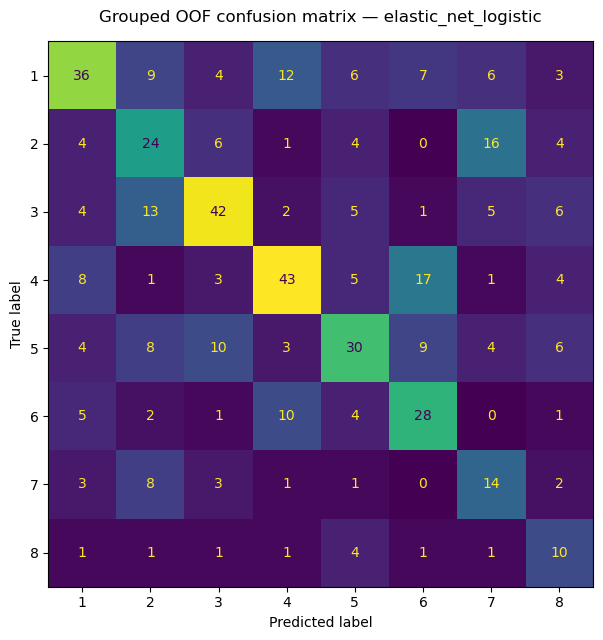

Wrote: C:\NCA_DATA\Analysis\PrelimML_NoSpectralClustering\ParentML_OOF_confusion_elastic_net_logistic.png

 random_forest


,precision,recall,f1-score,support
1,0.506,0.470,0.488,83.000
2,0.471,0.542,0.504,59.000
3,0.540,0.603,0.570,78.000
4,0.588,0.695,0.637,82.000
5,0.500,0.500,0.500,74.000
6,0.420,0.412,0.416,51.000
7,0.474,0.281,0.353,32.000
8,0.571,0.200,0.296,20.000
accuracy,0.514,0.514,0.514,0.514
macro avg,0.509,0.463,0.470,479.000


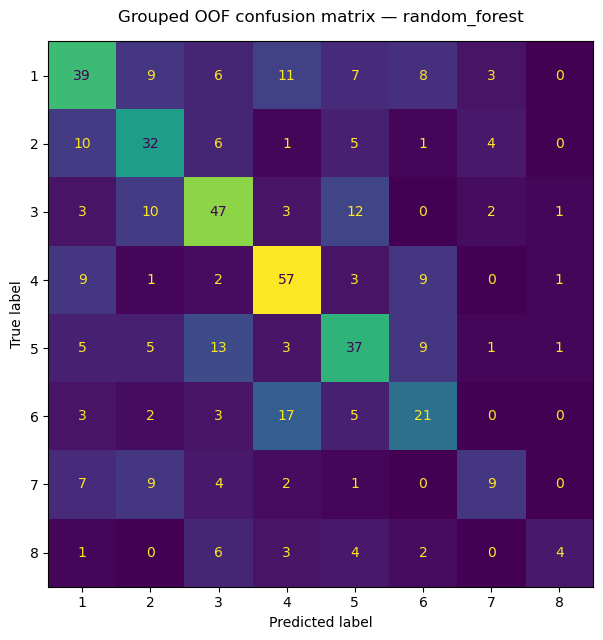

Wrote: C:\NCA_DATA\Analysis\PrelimML_NoSpectralClustering\ParentML_OOF_confusion_random_forest.png

 extra_trees


,precision,recall,f1-score,support
1,0.568,0.506,0.535,83.000
2,0.500,0.576,0.535,59.000
3,0.587,0.564,0.575,78.000
4,0.582,0.695,0.633,82.000
5,0.539,0.554,0.547,74.000
6,0.396,0.412,0.404,51.000
7,0.455,0.312,0.370,32.000
8,0.308,0.200,0.242,20.000
accuracy,0.528,0.528,0.528,0.528
macro avg,0.492,0.477,0.480,479.000


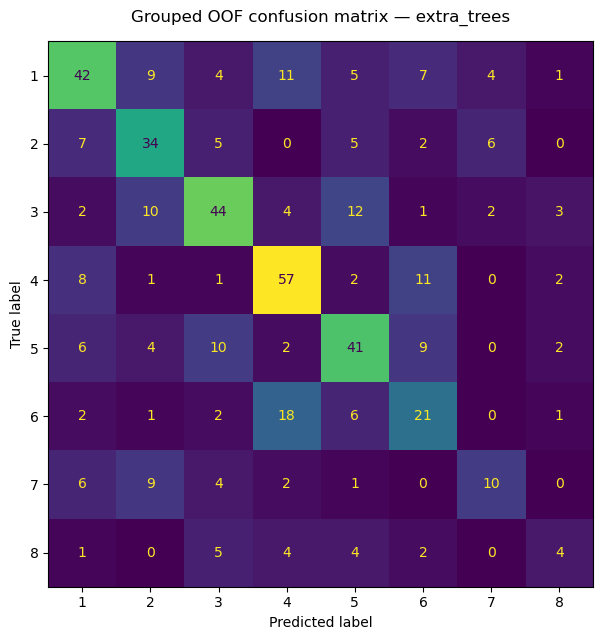

Wrote: C:\NCA_DATA\Analysis\PrelimML_NoSpectralClustering\ParentML_OOF_confusion_extra_trees.png


In [8]:
# =============================================================================
# OOF CONFUSION MATRICES
# =============================================================================

for model_name in MODELS:

    pred = oof[model_name]["pred"]

    print(
        "\n",
        model_name,
    )

    report = pd.DataFrame(
        classification_report(
            y,
            pred,
            labels=CLASS_LABELS,
            output_dict=True,
            zero_division=0,
        )
    ).T

    display(
        report.round(3)
    )

    cm = confusion_matrix(
        y,
        pred,
        labels=CLASS_LABELS,
    )

    fig, ax = plt.subplots(
        figsize=(7.5, 6.5)
    )

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_LABELS,
    ).plot(
        ax=ax,
        values_format="d",
        colorbar=False,
    )

    ax.set_title(
        f"Grouped OOF confusion matrix — {model_name}",
        fontsize=12,
        pad=14,
    )

    fig.tight_layout()

    path = (
        OUTPUT_DIR
        / f"ParentML_OOF_confusion_{model_name}.png"
    )

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print("Wrote:", path)


Mask: C:\NCA_DATA\templates\Masks\NCA_keepMask_v2.tif
CRS: PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DATUM["North American Datum 1983",SPHEROID["GRS 1980",6378137,298.257222101004]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Shape: 7857 x 10435
Resolution: (10.0, 10.0)
Unique valid values: [0 1]


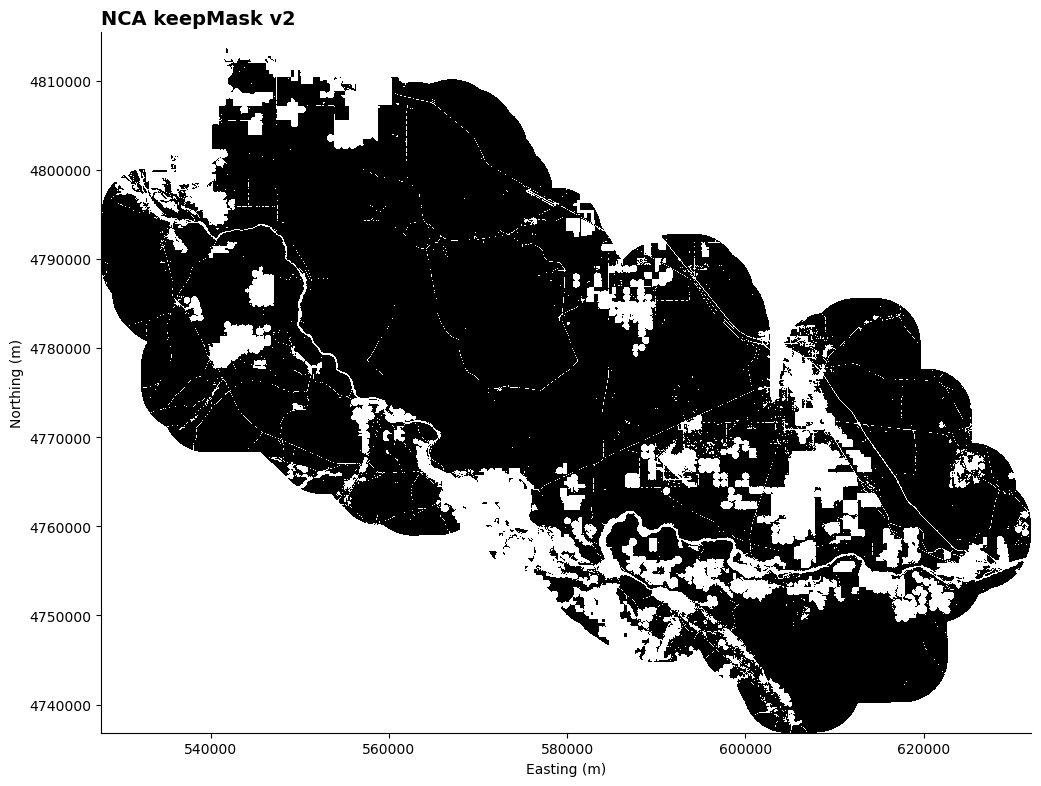

In [11]:
# =============================================================================
# DISPLAY NEW MASK V2
# =============================================================================

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import rasterio


MASK_PATH = Path(
    r"C:\NCA_DATA\templates\Masks\NCA_keepMask_v2.tif"
)


with rasterio.open(
    MASK_PATH
) as src:

    mask = src.read(
        1,
        masked=True,
    )

    extent = [
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top,
    ]

    print("Mask:", MASK_PATH)
    print("CRS:", src.crs)
    print("Shape:", src.height, "x", src.width)
    print("Resolution:", src.res)
    print(
        "Unique valid values:",
        np.unique(
            mask.compressed()
        )
    )


fig, ax = plt.subplots(
    figsize=(12, 10)
)

image = ax.imshow(
    mask,
    extent=extent,
    origin="upper",
    cmap="Greys",
    interpolation="none",
)

ax.set_title(
    "NCA keepMask v2",
    loc="left",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel(
    "Easting (m)"
)

ax.set_ylabel(
    "Northing (m)"
)

ax.ticklabel_format(
    style="plain",
    axis="both",
    useOffset=False,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

## 7. Leave-one-year-out validation

This is the important temporal-transfer test.

Each year is predicted using a model trained only on the other two years.


In [9]:
# =============================================================================
# LEAVE-ONE-YEAR-OUT
# =============================================================================

loyo_rows = []
loyo_predictions = []

for model_name, template in MODELS.items():

    for held_year in YEARS_TO_MAP:

        train_mask = (
            df["Year"] != held_year
        ).to_numpy()

        test_mask = (
            df["Year"] == held_year
        ).to_numpy()

        if not train_mask.any() or not test_mask.any():
            continue

        model = clone(template)

        model.fit(
            X[train_mask],
            y[train_mask],
        )

        pred = model.predict(
            X[test_mask]
        )

        proba = align_probabilities(
            model.predict_proba(
                X[test_mask]
            ),
            model.classes_,
        )

        scores = score_predictions(
            y[test_mask],
            pred,
            proba,
        )

        loyo_rows.append({
            "model": model_name,
            "held_out_year": held_year,
            "n_train": int(train_mask.sum()),
            "n_test": int(test_mask.sum()),
            **scores,
        })

        tmp = df.loc[
            test_mask,
            ["PlotID", "Year", "parent_cluster"],
        ].copy()

        tmp["model"] = model_name
        tmp["predicted_parent"] = pred

        loyo_predictions.append(
            tmp
        )


loyo_results = pd.DataFrame(
    loyo_rows
)

display(
    loyo_results.round(4)
)

loyo_predictions = pd.concat(
    loyo_predictions,
    ignore_index=True,
)


KeyboardInterrupt: 

## 8. Model-comparison figure


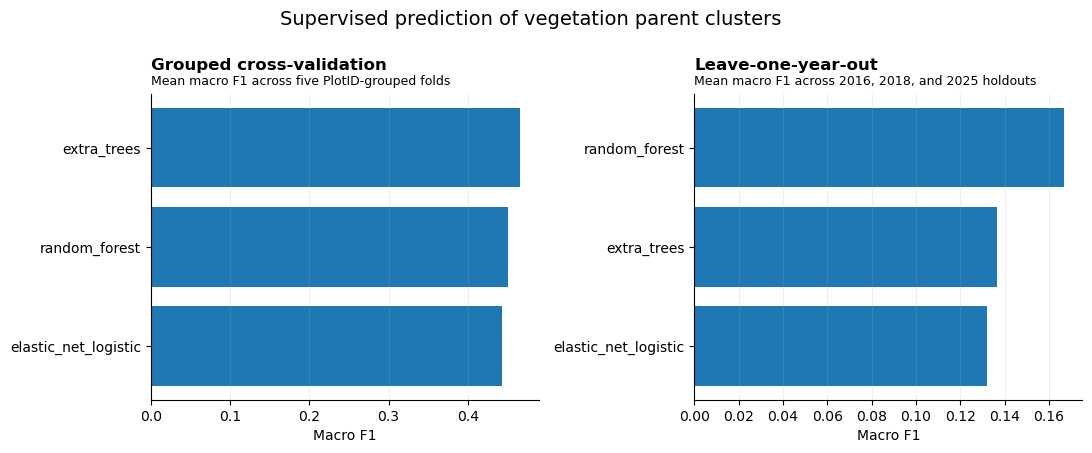

Wrote: C:\NCA_DATA\Analysis\PrelimML_NoSpectralClustering\ParentML_model_comparison_macroF1.png


In [ ]:
# =============================================================================
# MODEL COMPARISON
# =============================================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.5, 4.7),
)

cv_plot = (
    cv_summary
    .sort_values("macro_f1_mean")
)

axes[0].barh(
    cv_plot["model"],
    cv_plot["macro_f1_mean"],
)

axes[0].set_title(
    "Grouped cross-validation",
    loc="left",
    fontsize=12,
    fontweight="bold",
    pad=18,
)

axes[0].text(
    0.0,
    1.02,
    "Mean macro F1 across five PlotID-grouped folds",
    transform=axes[0].transAxes,
    fontsize=9,
    va="bottom",
)

axes[0].set_xlabel("Macro F1")
axes[0].grid(axis="x", alpha=0.2)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)


loyo_plot = (
    loyo_results
    .groupby("model", as_index=False)["macro_f1"]
    .mean()
    .sort_values("macro_f1")
)

axes[1].barh(
    loyo_plot["model"],
    loyo_plot["macro_f1"],
)

axes[1].set_title(
    "Leave-one-year-out",
    loc="left",
    fontsize=12,
    fontweight="bold",
    pad=18,
)

axes[1].text(
    0.0,
    1.02,
    "Mean macro F1 across 2016, 2018, and 2025 holdouts",
    transform=axes[1].transAxes,
    fontsize=9,
    va="bottom",
)

axes[1].set_xlabel("Macro F1")
axes[1].grid(axis="x", alpha=0.2)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.suptitle(
    "Supervised prediction of vegetation parent clusters",
    fontsize=14,
    y=0.98,
)

fig.subplots_adjust(
    left=0.17,
    right=0.98,
    bottom=0.15,
    top=0.80,
    wspace=0.40,
)

path = (
    OUTPUT_DIR
    / "ParentML_model_comparison_macroF1.png"
)

fig.savefig(
    path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Wrote:", path)


## 9. Save validation tables


In [ ]:
# =============================================================================
# SAVE VALIDATION RESULTS
# =============================================================================

cv_results.to_csv(
    OUTPUT_DIR
    / "ParentML_groupedCV_fold_metrics.csv",
    index=False,
)

cv_summary.to_csv(
    OUTPUT_DIR
    / "ParentML_groupedCV_summary.csv",
    index=False,
)

loyo_results.to_csv(
    OUTPUT_DIR
    / "ParentML_leaveYearOut_metrics.csv",
    index=False,
)

loyo_predictions.to_csv(
    OUTPUT_DIR
    / "ParentML_leaveYearOut_predictions.csv",
    index=False,
)

print("Validation tables written to:", OUTPUT_DIR)


Validation tables written to: C:\NCA_DATA\Analysis\PrelimML_NoSpectralClustering


## 10. Fit the selected preliminary mapping model on all three field years

The resulting TIFFs are descriptive preliminary maps because the pooled model is trained using observations from the same years being mapped.

Use the leave-one-year-out results above to judge temporal transfer.


In [ ]:
# =============================================================================
# POOLED MAPPING FIT
# =============================================================================

mapping_model = clone(
    MODELS[
        MODEL_FOR_MAPPING
    ]
)

mapping_model.fit(
    X,
    y,
)

print("Mapping model:", MODEL_FOR_MAPPING)
print("Classes:", mapping_model.classes_)


Mapping model: random_forest
Classes: [1 2 3 4 5 6 7 8]


## 11. Annual raster and mask QA


In [ ]:
# =============================================================================
# RASTER REGISTRY
# =============================================================================

def annual_k2_path(
    year,
):
    return (
        HARMONIC_ROOT
        / str(year)
        / f"{year}_K2_InterceptAmpPhase_nobs_RMSE.tif"
    )


for year in YEARS_TO_MAP:

    path = annual_k2_path(year)

    print(
        year,
        "->",
        path,
        "| exists:",
        path.exists(),
    )

    if not path.exists():
        raise FileNotFoundError(
            f"Missing annual raster:\n{path}"
        )


if not KEEP_MASK.exists():
    raise FileNotFoundError(
        f"Missing keep mask:\n{KEEP_MASK}"
    )


with rasterio.open(
    KEEP_MASK
) as mask_src:

    print("\nMask:")
    print(" shape:", (mask_src.height, mask_src.width))
    print(" CRS:", mask_src.crs)
    print(" transform:", mask_src.transform)
    print(" dtype:", mask_src.dtypes[0])
    print(" nodata:", mask_src.nodata)


2016 -> A:\NCA_DATA\S2_Harmonics\2016\2016_K2_InterceptAmpPhase_nobs_RMSE.tif | exists: True
2018 -> A:\NCA_DATA\S2_Harmonics\2018\2018_K2_InterceptAmpPhase_nobs_RMSE.tif | exists: True
2025 -> A:\NCA_DATA\S2_Harmonics\2025\2025_K2_InterceptAmpPhase_nobs_RMSE.tif | exists: True

Mask:
 shape: (7857, 10435)
 CRS: PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DATUM["North American Datum 1983",SPHEROID["GRS 1980",6378137,298.257222101004]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
 transform: | 10.00, 0.00, 527740.00|
| 0.00,-10.00, 4815410.00|
| 0.00, 0.00, 1.00|
 dtype: uint8
 nodata: None


## 12. Match the 45 training features to raster band descriptions


In [ ]:
# =============================================================================
# BAND MATCHING
# =============================================================================

def get_band_names(
    src,
):
    return [
        (
            str(desc).strip()
            if desc is not None
            and str(desc).strip()
            else f"band_{i}"
        )
        for i, desc in enumerate(
            src.descriptions,
            start=1,
        )
    ]


def normalize_name(
    x,
):
    return str(x).strip().lower()


def ia_band_indexes(
    src,
    ia_cols,
):
    names = get_band_names(
        src
    )

    lookup = {
        normalize_name(name): i
        for i, name in enumerate(
            names,
            start=1,
        )
    }

    indexes = []
    missing = []

    for feature in ia_cols:

        key = normalize_name(
            feature
        )

        if key not in lookup:
            missing.append(
                feature
            )
        else:
            indexes.append(
                lookup[key]
            )

    if missing:
        raise KeyError(
            "Missing IA45 raster bands:\n"
            + "\n".join(missing)
        )

    if len(indexes) != EXPECTED_D:
        raise RuntimeError(
            f"Expected {EXPECTED_D} matched raster bands; "
            f"found {len(indexes)}."
        )

    return indexes


for year in YEARS_TO_MAP:

    with rasterio.open(
        annual_k2_path(year)
    ) as src:

        idx = ia_band_indexes(
            src,
            IA_COLS,
        )

        print(
            year,
            "IA45 indexes:",
            idx
        )


2016 IA45 indexes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]
2018 IA45 indexes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]
2025 IA45 indexes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]


## 13. Blockwise raster prediction

The keep mask is read directly when it already matches the harmonic grid.

If its grid differs, a nearest-neighbor `WarpedVRT` is used only for the mask.

Outputs per year:

- `ParentML_<model>_<year>_class.tif`
- `ParentML_<model>_<year>_uncertainty.tif`

The uncertainty TIFF contains:

1. maximum class probability
2. probability margin
3. prediction entropy

Eight-band class-probability TIFFs are disabled by default.


In [ ]:
# =============================================================================
# BLOCKWISE RASTER CLASSIFICATION
# =============================================================================

def predictive_entropy(
    proba,
):
    eps = 1e-12

    return -np.sum(
        proba
        * np.log(
            np.maximum(
                proba,
                eps,
            )
        ),
        axis=1,
    )


def grids_match(
    src_a,
    src_b,
):
    return (
        src_a.width == src_b.width
        and src_a.height == src_b.height
        and src_a.transform == src_b.transform
        and src_a.crs == src_b.crs
    )


def classify_year(
    year,
    model,
):

    src_path = annual_k2_path(
        year
    )

    class_path = (
        OUTPUT_DIR
        / f"ParentML_{MODEL_FOR_MAPPING}_{year}_class.tif"
    )

    uncertainty_path = (
        OUTPUT_DIR
        / f"ParentML_{MODEL_FOR_MAPPING}_{year}_uncertainty.tif"
    )

    probability_path = (
        OUTPUT_DIR
        / f"ParentML_{MODEL_FOR_MAPPING}_{year}_probabilities.tif"
    )

    print(
        "\n"
        + "=" * 100
    )

    print(
        "CLASSIFYING",
        year
    )

    print(
        "=" * 100
    )

    with rasterio.open(
        src_path
    ) as src, rasterio.open(
        KEEP_MASK
    ) as mask_src:

        indexes = ia_band_indexes(
            src,
            IA_COLS,
        )

        use_direct_mask = grids_match(
            src,
            mask_src,
        )

        mask_vrt = None

        if use_direct_mask:

            print(
                "Keep mask already matches annual raster grid."
            )

        else:

            print(
                "Keep mask grid differs; using nearest-neighbor WarpedVRT."
            )

            mask_vrt = WarpedVRT(
                mask_src,
                crs=src.crs,
                transform=src.transform,
                width=src.width,
                height=src.height,
                resampling=Resampling.nearest,
            )

        class_profile = src.profile.copy()

        class_profile.update(
            driver="GTiff",
            count=1,
            dtype="uint8",
            nodata=0,
            compress=COMPRESS,
            tiled=True,
            BIGTIFF="IF_SAFER",
        )

        uncertainty_profile = src.profile.copy()

        uncertainty_profile.update(
            driver="GTiff",
            count=3,
            dtype="float32",
            nodata=-9999.0,
            compress=COMPRESS,
            predictor=3,
            tiled=True,
            BIGTIFF="IF_SAFER",
        )

        probability_profile = src.profile.copy()

        probability_profile.update(
            driver="GTiff",
            count=len(CLASS_LABELS),
            dtype="float32",
            nodata=-9999.0,
            compress=COMPRESS,
            predictor=3,
            tiled=True,
            BIGTIFF="IF_SAFER",
        )

        with rasterio.open(
            class_path,
            "w",
            **class_profile,
        ) as class_dst:

            class_dst.set_band_description(
                1,
                "predicted_parent_cluster",
            )

            uncertainty_dst = None
            probability_dst = None

            try:

                if WRITE_UNCERTAINTY_RASTER:

                    uncertainty_dst = rasterio.open(
                        uncertainty_path,
                        "w",
                        **uncertainty_profile,
                    )

                    uncertainty_dst.set_band_description(
                        1,
                        "max_probability",
                    )

                    uncertainty_dst.set_band_description(
                        2,
                        "probability_margin",
                    )

                    uncertainty_dst.set_band_description(
                        3,
                        "prediction_entropy",
                    )

                if WRITE_CLASS_PROBABILITY_RASTER:

                    probability_dst = rasterio.open(
                        probability_path,
                        "w",
                        **probability_profile,
                    )

                    for band_no, cls in enumerate(
                        CLASS_LABELS,
                        start=1,
                    ):

                        probability_dst.set_band_description(
                            band_no,
                            f"prob_parent_{int(cls)}",
                        )

                total_keep = 0
                total_valid = 0

                for _, window in src.block_windows(
                    1
                ):

                    if use_direct_mask:

                        keep = mask_src.read(
                            1,
                            window=window,
                            masked=False,
                        )

                    else:

                        keep = mask_vrt.read(
                            1,
                            window=window,
                            masked=False,
                        )

                    keep_valid = (
                        np.isfinite(
                            keep
                        )
                        & (
                            keep > 0
                        )
                    )

                    total_keep += int(
                        keep_valid.sum()
                    )

                    features = src.read(
                        indexes,
                        window=window,
                        masked=False,
                    ).astype(
                        np.float32
                    )

                    # Shape:
                    # bands × rows × cols -> rows × cols × bands
                    features = np.moveaxis(
                        features,
                        0,
                        -1,
                    )

                    valid = (
                        keep_valid.copy()
                    )

                    valid &= np.isfinite(
                        features
                    ).all(
                        axis=2
                    )

                    if src.nodata is not None:

                        valid &= ~np.any(
                            np.isclose(
                                features,
                                src.nodata,
                            ),
                            axis=2,
                        )

                    total_valid += int(
                        valid.sum()
                    )

                    class_block = np.zeros(
                        (
                            int(window.height),
                            int(window.width),
                        ),
                        dtype=np.uint8,
                    )

                    uncertainty_block = np.full(
                        (
                            3,
                            int(window.height),
                            int(window.width),
                        ),
                        -9999.0,
                        dtype=np.float32,
                    )

                    probability_block = None

                    if WRITE_CLASS_PROBABILITY_RASTER:

                        probability_block = np.full(
                            (
                                len(CLASS_LABELS),
                                int(window.height),
                                int(window.width),
                            ),
                            -9999.0,
                            dtype=np.float32,
                        )

                    if valid.any():

                        X_block = features[
                            valid
                        ]

                        pred = model.predict(
                            X_block
                        ).astype(
                            np.uint8
                        )

                        raw_proba = model.predict_proba(
                            X_block
                        )

                        proba = align_probabilities(
                            raw_proba,
                            model.classes_,
                        )

                        class_block[
                            valid
                        ] = pred

                        sorted_p = np.sort(
                            proba,
                            axis=1,
                        )

                        max_p = sorted_p[
                            :,
                            -1,
                        ]

                        margin = (
                            sorted_p[
                                :,
                                -1,
                            ]
                            - sorted_p[
                                :,
                                -2,
                            ]
                        )

                        entropy = predictive_entropy(
                            proba
                        )

                        uncertainty_block[
                            0
                        ][
                            valid
                        ] = max_p.astype(
                            np.float32
                        )

                        uncertainty_block[
                            1
                        ][
                            valid
                        ] = margin.astype(
                            np.float32
                        )

                        uncertainty_block[
                            2
                        ][
                            valid
                        ] = entropy.astype(
                            np.float32
                        )

                        if probability_block is not None:

                            for j in range(
                                len(CLASS_LABELS)
                            ):

                                probability_block[
                                    j
                                ][
                                    valid
                                ] = proba[
                                    :,
                                    j,
                                ].astype(
                                    np.float32
                                )

                    class_dst.write(
                        class_block,
                        1,
                        window=window,
                    )

                    if uncertainty_dst is not None:

                        uncertainty_dst.write(
                            uncertainty_block,
                            window=window,
                        )

                    if probability_dst is not None:

                        probability_dst.write(
                            probability_block,
                            window=window,
                        )

                print(
                    "Keep-mask pixels:",
                    f"{total_keep:,}"
                )

                print(
                    "Valid IA45 pixels classified:",
                    f"{total_valid:,}"
                )

            finally:

                if uncertainty_dst is not None:
                    uncertainty_dst.close()

                if probability_dst is not None:
                    probability_dst.close()

                if mask_vrt is not None:
                    mask_vrt.close()

    print(
        "Wrote class:",
        class_path
    )

    if WRITE_UNCERTAINTY_RASTER:
        print(
            "Wrote uncertainty:",
            uncertainty_path
        )

    if WRITE_CLASS_PROBABILITY_RASTER:
        print(
            "Wrote probabilities:",
            probability_path
        )

    return {
        "Year": year,
        "class_path": class_path,
        "uncertainty_path": (
            uncertainty_path
            if WRITE_UNCERTAINTY_RASTER
            else None
        ),
        "probability_path": (
            probability_path
            if WRITE_CLASS_PROBABILITY_RASTER
            else None
        ),
    }


## 14. Run only 2016, 2018, and 2025


In [ ]:
# =============================================================================
# MAP THE THREE REQUESTED YEARS
# =============================================================================

map_outputs = []

for year in YEARS_TO_MAP:

    result = classify_year(
        year=year,
        model=mapping_model,
    )

    map_outputs.append(
        result
    )


map_outputs = pd.DataFrame(
    map_outputs
)

display(
    map_outputs
)

map_outputs.to_csv(
    OUTPUT_DIR
    / "ParentML_preliminary_map_outputs.csv",
    index=False,
)



CLASSIFYING 2016
Keep mask already matches annual raster grid.
Keep-mask pixels: 36,619,399
Valid IA45 pixels classified: 36,367,546
Wrote class: C:\NCA_DATA\Analysis\PrelimML_NoSpectralClustering\ParentML_random_forest_2016_class.tif
Wrote uncertainty: C:\NCA_DATA\Analysis\PrelimML_NoSpectralClustering\ParentML_random_forest_2016_uncertainty.tif

CLASSIFYING 2018
Keep mask already matches annual raster grid.
Keep-mask pixels: 36,619,399
Valid IA45 pixels classified: 36,493,754
Wrote class: C:\NCA_DATA\Analysis\PrelimML_NoSpectralClustering\ParentML_random_forest_2018_class.tif
Wrote uncertainty: C:\NCA_DATA\Analysis\PrelimML_NoSpectralClustering\ParentML_random_forest_2018_uncertainty.tif

CLASSIFYING 2025
Keep mask already matches annual raster grid.
Keep-mask pixels: 36,619,399
Valid IA45 pixels classified: 36,527,562
Wrote class: C:\NCA_DATA\Analysis\PrelimML_NoSpectralClustering\ParentML_random_forest_2025_class.tif
Wrote uncertainty: C:\NCA_DATA\Analysis\PrelimML_NoSpectralClust

,Year,class_path,uncertainty_path,probability_path
0,2016,C:\NCA_DATA\Analysis\PrelimML_NoSpectralCluste...,C:\NCA_DATA\Analysis\PrelimML_NoSpectralCluste...,None
1,2018,C:\NCA_DATA\Analysis\PrelimML_NoSpectralCluste...,C:\NCA_DATA\Analysis\PrelimML_NoSpectralCluste...,None
2,2025,C:\NCA_DATA\Analysis\PrelimML_NoSpectralCluste...,C:\NCA_DATA\Analysis\PrelimML_NoSpectralCluste...,None


In [ ]:
# =============================================================================
# CLASSIFIED RASTER SUMMARY
# =============================================================================

for year in YEARS_TO_MAP:

    class_path = (
        OUTPUT_DIR
        / f"ParentML_{MODEL_FOR_MAPPING}_{year}_class.tif"
    )

    print(
        "\n"
        + "=" * 90
    )

    print(
        f"CLASSIFIED RASTER SUMMARY — {year}"
    )

    print(
        "=" * 90
    )

    if not class_path.exists():
        print(
            "Missing:",
            class_path
        )
        continue

    with rasterio.open(
        class_path
    ) as src:

        arr = src.read(
            1,
            masked=False,
        )

        valid = (
            arr > 0
        )

        n_valid = int(
            valid.sum()
        )

        print(
            "Path:",
            class_path
        )

        print(
            "Shape:",
            arr.shape
        )

        print(
            "CRS:",
            src.crs
        )

        print(
            "Valid classified pixels:",
            f"{n_valid:,}"
        )

        if n_valid == 0:
            print(
                "No classified pixels found."
            )
            continue

        values, counts = np.unique(
            arr[valid],
            return_counts=True,
        )

        summary = pd.DataFrame({
            "parent_cluster": values.astype(int),
            "n_pixels": counts.astype(np.int64),
        })

        summary["percent"] = (
            100
            * summary["n_pixels"]
            / n_valid
        )

        display(
            summary
        )


CLASSIFIED RASTER SUMMARY — 2016
Path: C:\NCA_DATA\Analysis\PrelimML_NoSpectralClustering\ParentML_random_forest_2016_class.tif
Shape: (7857, 10435)
CRS: PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DATUM["North American Datum 1983",SPHEROID["GRS 1980",6378137,298.257222101004]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Valid classified pixels: 36,367,546


,parent_cluster,n_pixels,percent
0,1,6129083,16.853166
1,2,2359137,6.486929
2,3,8528767,23.451588
3,4,6732660,18.512825
4,5,6438888,17.705038
5,6,3381215,9.297342
6,7,1514629,4.164782
7,8,1283167,3.528330



CLASSIFIED RASTER SUMMARY — 2018
Path: C:\NCA_DATA\Analysis\PrelimML_NoSpectralClustering\ParentML_random_forest_2018_class.tif
Shape: (7857, 10435)
CRS: PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DATUM["North American Datum 1983",SPHEROID["GRS 1980",6378137,298.257222101004]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Valid classified pixels: 36,493,754


,parent_cluster,n_pixels,percent
0,1,2467897,6.762519
1,2,2339403,6.410420
2,3,6295700,17.251445
3,4,14123409,38.700894
4,5,6968420,19.094829
5,6,2981593,8.170146
6,7,594230,1.628306
7,8,723102,1.981440



CLASSIFIED RASTER SUMMARY — 2025
Path: C:\NCA_DATA\Analysis\PrelimML_NoSpectralClustering\ParentML_random_forest_2025_class.tif
Shape: (7857, 10435)
CRS: PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DATUM["North American Datum 1983",SPHEROID["GRS 1980",6378137,298.257222101004]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Valid classified pixels: 36,527,562


,parent_cluster,n_pixels,percent
0,1,7134286,19.531241
1,2,2660132,7.282534
2,3,2825324,7.734773
3,4,15109795,41.365463
4,5,702511,1.923235
5,6,3774955,10.334539
6,7,2250346,6.160679
7,8,2070213,5.667537


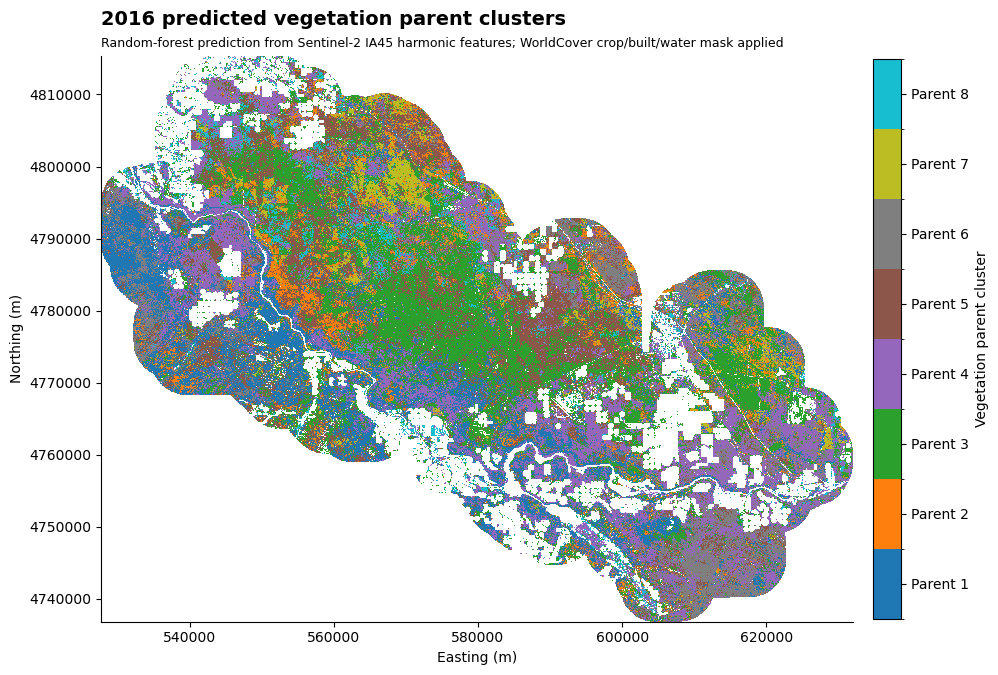

Wrote: C:\NCA_DATA\Analysis\PrelimML_NoSpectralClustering\ParentML_random_forest_2016_map.png


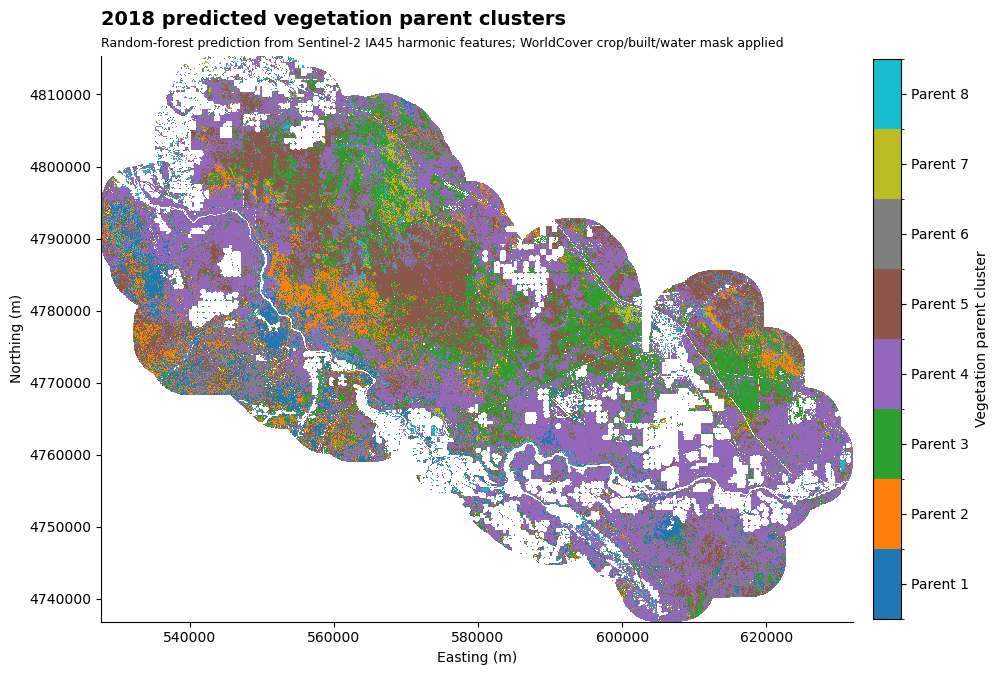

Wrote: C:\NCA_DATA\Analysis\PrelimML_NoSpectralClustering\ParentML_random_forest_2018_map.png


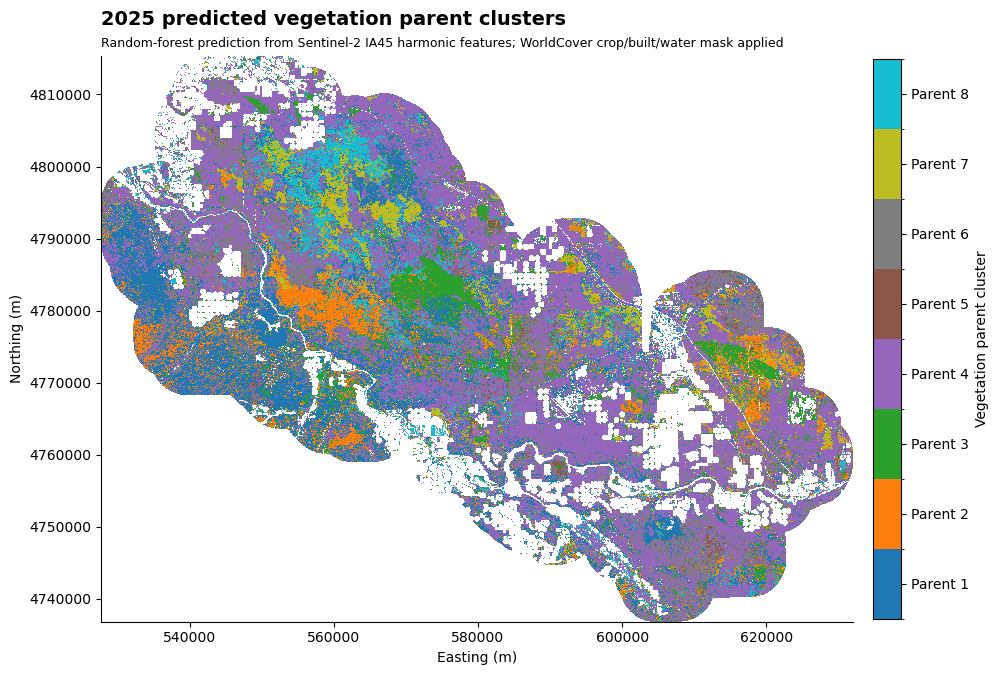

Wrote: C:\NCA_DATA\Analysis\PrelimML_NoSpectralClustering\ParentML_random_forest_2025_map.png


In [ ]:
# =============================================================================
# PLOT CLASSIFIED PARENT-CLUSTER RASTERS
# =============================================================================

from matplotlib.colors import BoundaryNorm

# Downsample only for display.
# 4 means approximately 40 m display pixels from the native 10 m raster.
DISPLAY_DOWNSAMPLE = 4

# One fixed categorical palette for all years.
cmap = plt.get_cmap(
    "tab10",
    8,
)

norm = BoundaryNorm(
    np.arange(
        0.5,
        9.5,
        1.0,
    ),
    cmap.N,
)


for year in YEARS_TO_MAP:

    class_path = (
        OUTPUT_DIR
        / f"ParentML_{MODEL_FOR_MAPPING}_{year}_class.tif"
    )

    if not class_path.exists():
        print(
            "Missing:",
            class_path,
        )
        continue

    with rasterio.open(
        class_path
    ) as src:

        display_height = max(
            1,
            src.height // DISPLAY_DOWNSAMPLE,
        )

        display_width = max(
            1,
            src.width // DISPLAY_DOWNSAMPLE,
        )

        arr = src.read(
            1,
            out_shape=(
                1,
                display_height,
                display_width,
            ),
            resampling=Resampling.nearest,
            masked=False,
        )

        # 0 is the nodata / masked-out class.
        arr = np.ma.masked_where(
            arr == 0,
            arr,
        )

        extent = [
            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top,
        ]

    fig, ax = plt.subplots(
        figsize=(
            10,
            10,
        )
    )

    image = ax.imshow(
        arr,
        cmap=cmap,
        norm=norm,
        extent=extent,
        origin="upper",
        interpolation="nearest",
    )

    ax.set_title(
        f"{year} predicted vegetation parent clusters",
        loc="left",
        fontsize=14,
        fontweight="bold",
        pad=22,
    )

    ax.text(
        0.0,
        1.01,
        (
            "Random-forest prediction from Sentinel-2 IA45 harmonic features; "
            "WorldCover crop/built/water mask applied"
        ),
        transform=ax.transAxes,
        fontsize=9,
        ha="left",
        va="bottom",
    )

    ax.set_xlabel(
        "Easting (m)"
    )

    ax.set_ylabel(
        "Northing (m)"
    )

    ax.ticklabel_format(
        style="plain",
        axis="both",
        useOffset=False,
    )

    # Discrete class colorbar.
    cbar = fig.colorbar(
        image,
        ax=ax,
        orientation="vertical",
        fraction=0.035,
        pad=0.025,
        ticks=CLASS_LABELS,
    )

    cbar.set_label(
        "Vegetation parent cluster",
        fontsize=10,
    )

    cbar.ax.set_yticklabels(
        [
            f"Parent {i}"
            for i in CLASS_LABELS
        ]
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.subplots_adjust(
        left=0.10,
        right=0.90,
        bottom=0.08,
        top=0.90,
    )

    figure_path = (
        OUTPUT_DIR
        / f"ParentML_{MODEL_FOR_MAPPING}_{year}_map.png"
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Wrote:",
        figure_path,
    )

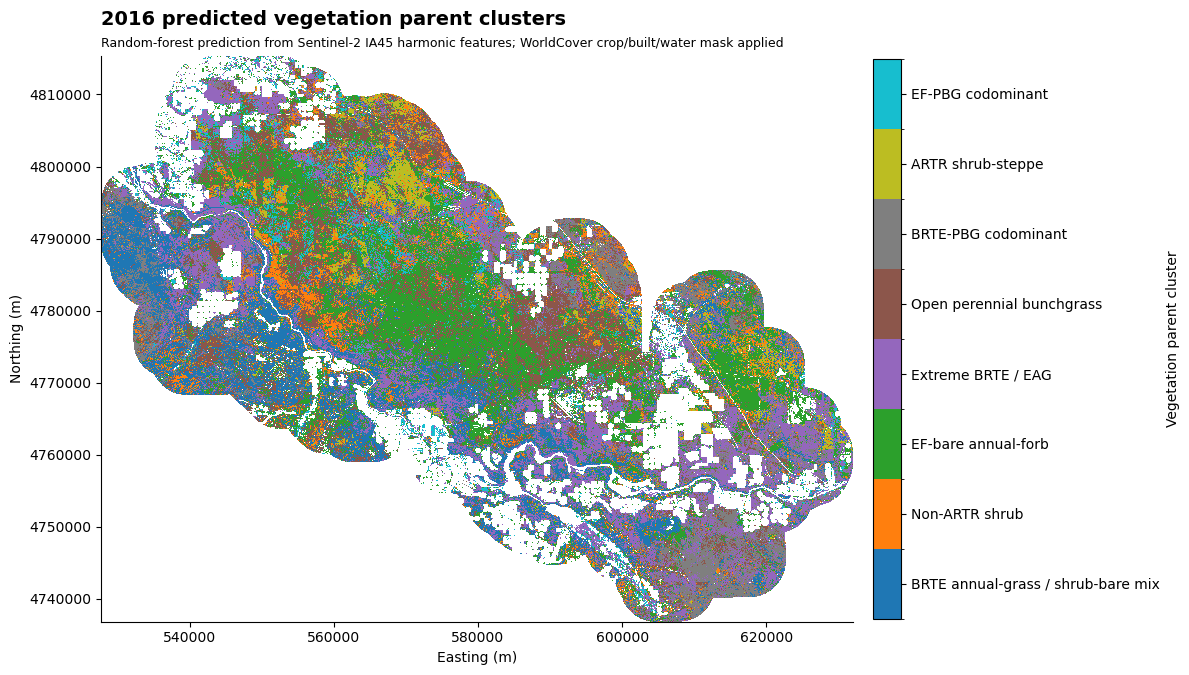

Wrote: C:\NCA_DATA\Analysis\PrelimML_NoSpectralClustering\ParentML_random_forest_2016_map.png


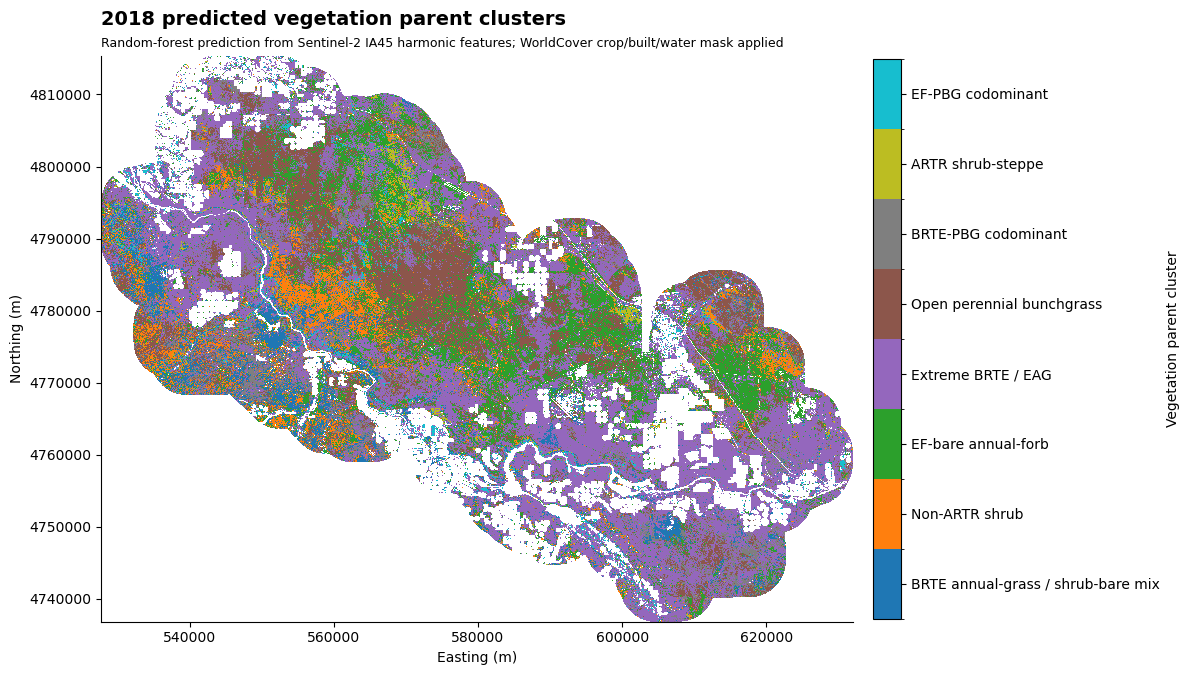

Wrote: C:\NCA_DATA\Analysis\PrelimML_NoSpectralClustering\ParentML_random_forest_2018_map.png


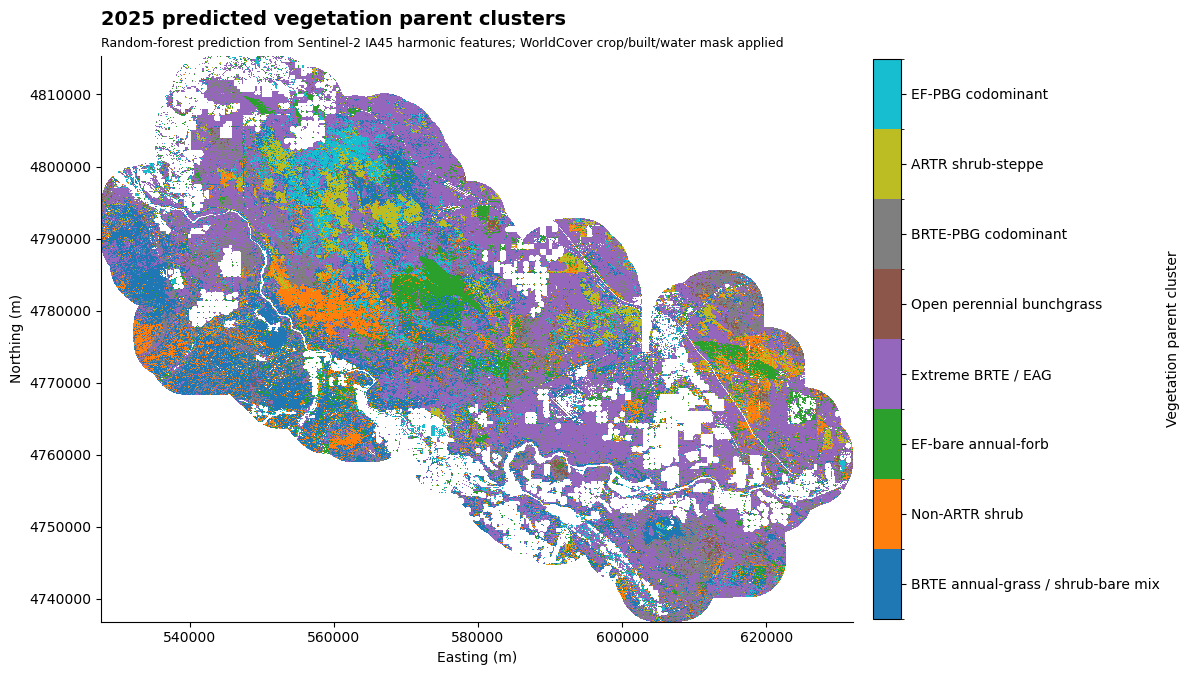

Wrote: C:\NCA_DATA\Analysis\PrelimML_NoSpectralClustering\ParentML_random_forest_2025_map.png


In [10]:
# =============================================================================
# PLOT CLASSIFIED PARENT-CLUSTER RASTERS
# =============================================================================

from matplotlib.colors import BoundaryNorm

# One fixed categorical palette for all years.
cmap = plt.get_cmap(
    "tab10",
    8,
)

norm = BoundaryNorm(
    np.arange(
        0.5,
        9.5,
        1.0,
    ),
    cmap.N,
)


for year in YEARS_TO_MAP:

    class_path = (
        OUTPUT_DIR
        / f"ParentML_{MODEL_FOR_MAPPING}_{year}_class.tif"
    )

    if not class_path.exists():

        print(
            "Missing:",
            class_path,
        )

        continue

    with rasterio.open(
        class_path
    ) as src:

        arr = src.read(
            1,
            masked=False,
        )

        # 0 is the nodata / masked-out class.
        arr = np.ma.masked_where(
            arr == 0,
            arr,
        )

        extent = [
            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top,
        ]

    fig, ax = plt.subplots(
        figsize=(
            10,
            10,
        )
    )

    image = ax.imshow(
        arr,
        cmap=cmap,
        norm=norm,
        extent=extent,
        origin="upper",
        interpolation="nearest",
    )

    ax.set_title(
        f"{year} predicted vegetation parent clusters",
        loc="left",
        fontsize=14,
        fontweight="bold",
        pad=22,
    )

    ax.text(
        0.0,
        1.01,
        (
            "Random-forest prediction from Sentinel-2 IA45 harmonic features; "
            "WorldCover crop/built/water mask applied"
        ),
        transform=ax.transAxes,
        fontsize=9,
        ha="left",
        va="bottom",
    )

    ax.set_xlabel(
        "Easting (m)"
    )

    ax.set_ylabel(
        "Northing (m)"
    )

    ax.ticklabel_format(
        style="plain",
        axis="both",
        useOffset=False,
    )

    # Discrete class colorbar.
    cbar = fig.colorbar(
        image,
        ax=ax,
        orientation="vertical",
        fraction=0.035,
        pad=0.025,
        ticks=CLASS_LABELS,
    )

    cbar.set_label(
        "Vegetation parent cluster",
        fontsize=10,
    )

    cbar.ax.set_yticklabels(
        [
            "BRTE annual-grass / shrub-bare mix",
            "Non-ARTR shrub",
            "EF-bare annual-forb",
            "Extreme BRTE / EAG",
            "Open perennial bunchgrass",
            "BRTE-PBG codominant",
            "ARTR shrub-steppe",
            "EF-PBG codominant",
        ]
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.subplots_adjust(
        left=0.10,
        right=0.90,
        bottom=0.08,
        top=0.90,
    )

    figure_path = (
        OUTPUT_DIR
        / f"ParentML_{MODEL_FOR_MAPPING}_{year}_map.png"
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Wrote:",
        figure_path,
    )

## 15. Final interpretation

This preliminary workflow answers a different question from independent optical FCM.

- **Independent optical clustering:** do ecological states naturally emerge as optical partitions?
- **Supervised parent mapping:** can a classifier learn decision boundaries that predict the eight vegetation parents from IA45?

Strong supervised performance alongside weak optical-cluster/vegetation-cluster ARI would demonstrate that the vegetation states are predictable without being natural one-to-one partitions of optical space.

The mapped TIFFs are exploratory products. The leave-one-year-out metrics are the stronger evidence for whether the learned relationship transfers through time.
